# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

Andy Liu

March 1, 2026

In [ ]:
pokemon = pd.read_csv(fp)
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [ ]:
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

Text(0.5, 1.0, 'Correlation between Pokemon Attack and Defense')

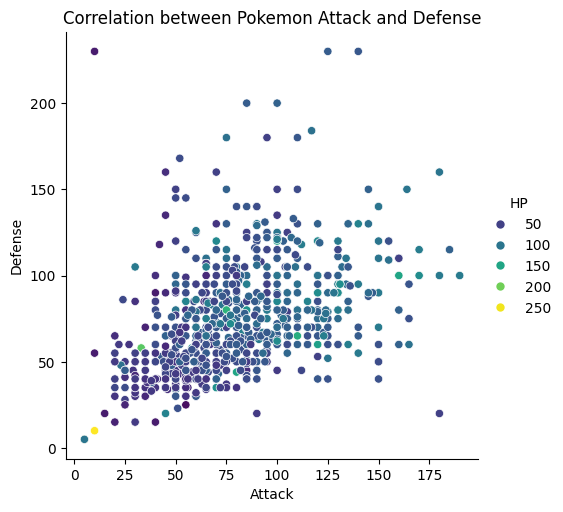

In [ ]:
# Your code here . . .
sns.relplot(data=pokemon,
            x='Attack',
            y='Defense',
            hue='HP',
            palette='viridis')
plt.title("Correlation between Pokemon Attack and Defense")

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

Text(0.5, 1.2, 'Attack vs total for all Pokemon')

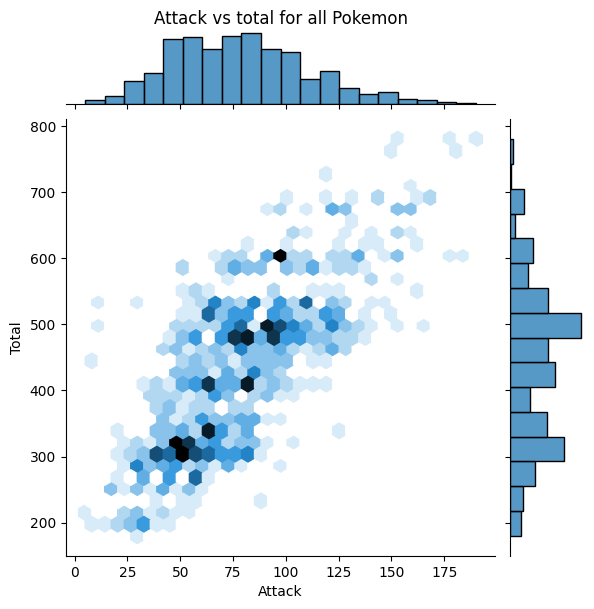

In [ ]:
# Your code here . . .
sns.jointplot(data=pokemon,
             x='Attack',
             y='Total',
             kind='hex',
             gridsize=30)
plt.title("Attack vs total for all Pokemon", y=1.2)

From the plot, I observed there is a positive correlation between Attack and Total stats, so pokemon with higher attacks also tend to have higher overall stats. Pokemon total stats also are clumped around certain numbers rather than randomly distributed.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

Text(0.5, 1.0, 'Counts of Pokemon of Type 2')

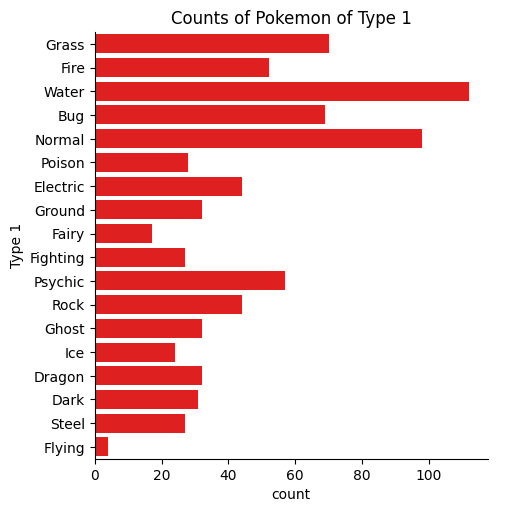

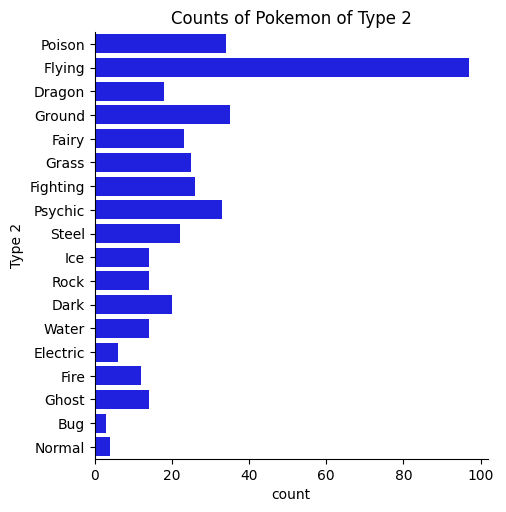

In [ ]:
# Your code here . . .
sns.catplot(data=pokemon,
            y='Type 1',
            kind = 'count',
            color='red')
plt.title("Counts of Pokemon of Type 1")

sns.catplot(data=pokemon,
            y='Type 2',
            kind = 'count',
            color='blue')
plt.title("Counts of Pokemon of Type 2")

Water is the most common Type 1 with Normal at a close second, while Flying is the rarest Type 1. Flying is the most common Type 2 by far, and Bug is the rarest Type 2.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .

# Q4 Do Pokemon with higher speed also have higher attack?

Text(0.5, 1.2, 'Correlation between Pokemon Speed and Attack')

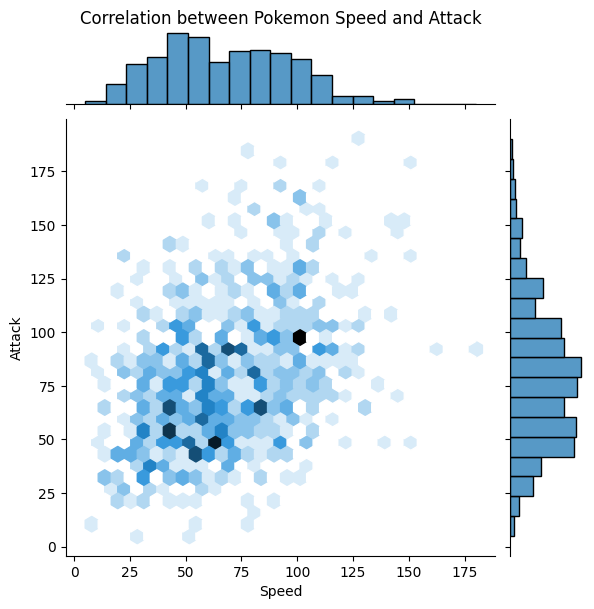

In [ ]:
# Your code here . . .
sns.jointplot(data=pokemon,
             x='Speed',
             y='Attack',
             kind='hex',
             gridsize=30)
plt.title("Correlation between Pokemon Speed and Attack", y=1.2)

It seems that there is a loose correlation between pokemon speed and attack, but it may be that higher speed pokemon tend to have a higher attack as well.

# Q5 Do legendary Pokemon have higher stats than non-legendary Pokemon?

Text(0.5, 1.0, 'Total Stats of Legendary vs Non-Legendary Pokemon')

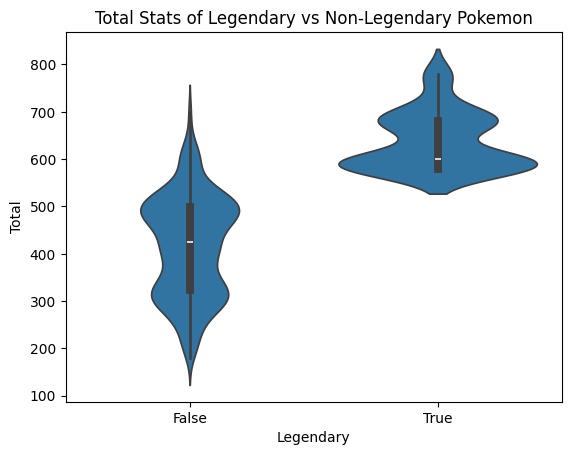

In [ ]:
sns.violinplot(data=pokemon,
               x='Legendary',
               y='Total')
plt.title("Total Stats of Legendary vs Non-Legendary Pokemon")

We can confidently say Legendary Pokemon tend to have much higher total stats compared to Non-Legendary Pokemon. The highest stats pokemon are legendary.

# Q6 Do Pokemon stats change over generations?

Text(0.5, 1.05, 'Stats of Pokemon Across Generations')

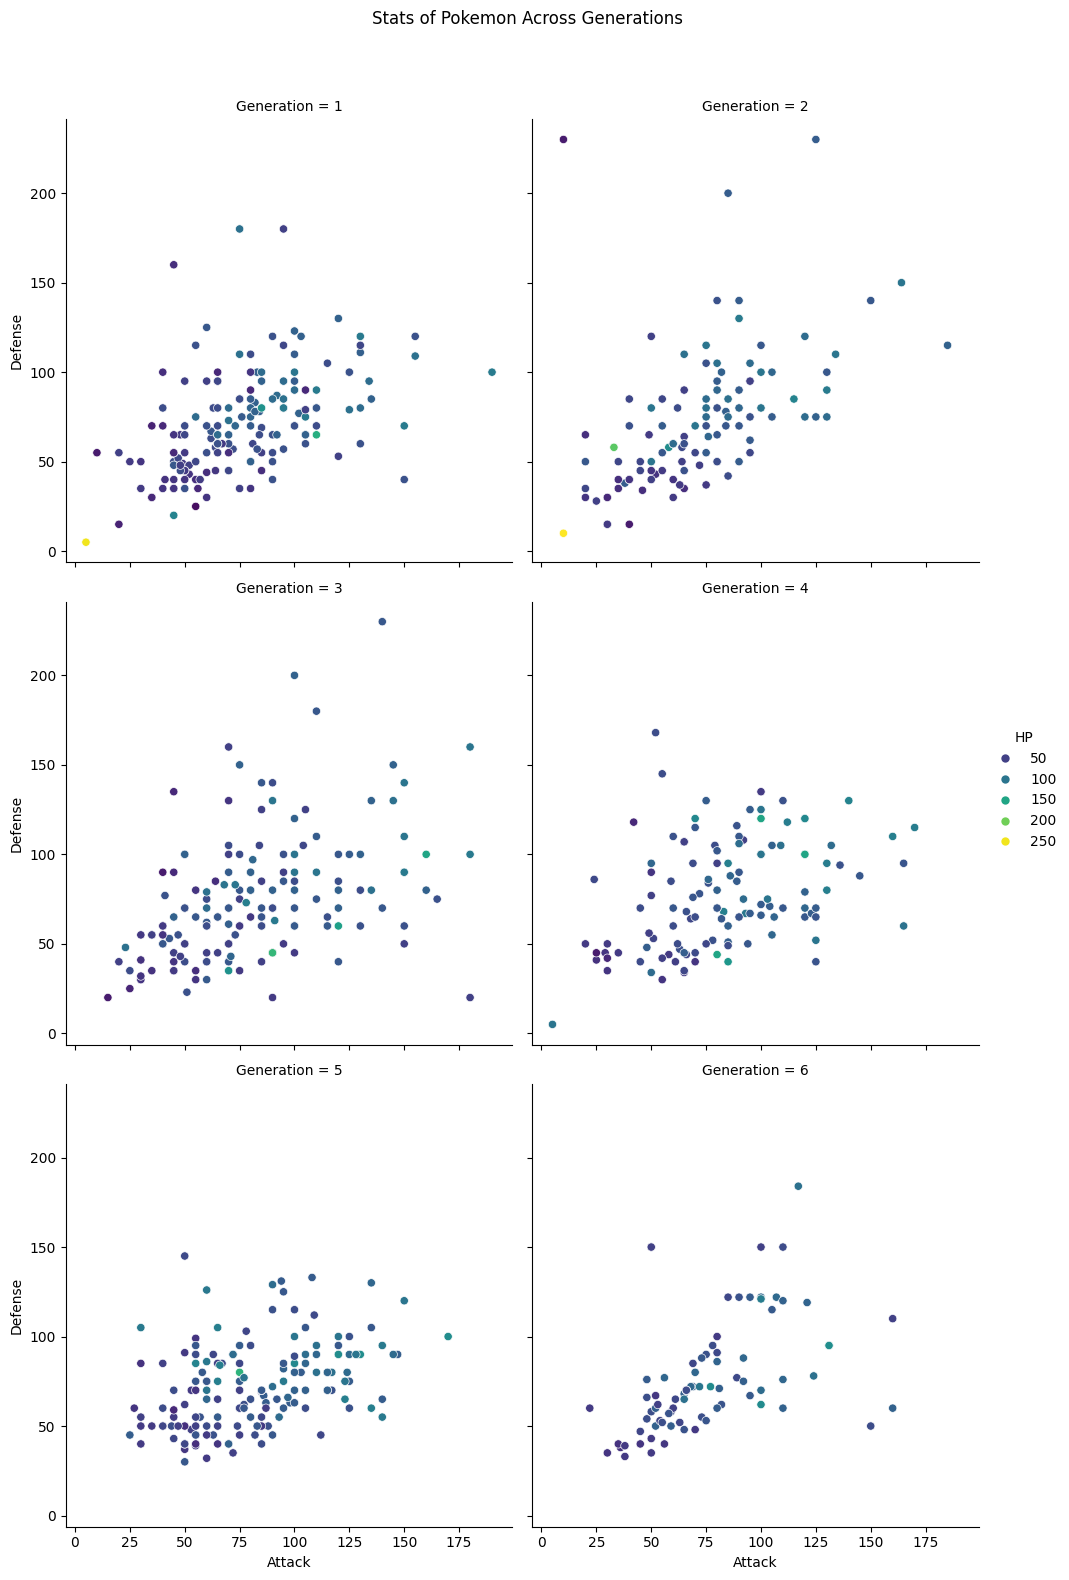

In [ ]:
sns.relplot(data=pokemon,
            x='Attack',
            y='Defense',
            hue='HP',
            col='Generation',
            col_wrap=2,
            palette='viridis')
plt.suptitle("Stats of Pokemon Across Generations", y=1.05)

Across generations, it appears Pokemon have their stats distributed pretty similarly. No generation has significantly higher or lower stats compared to others and are spread out pretty similarly. This means Pokemon stats don't get higher over time.